
Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




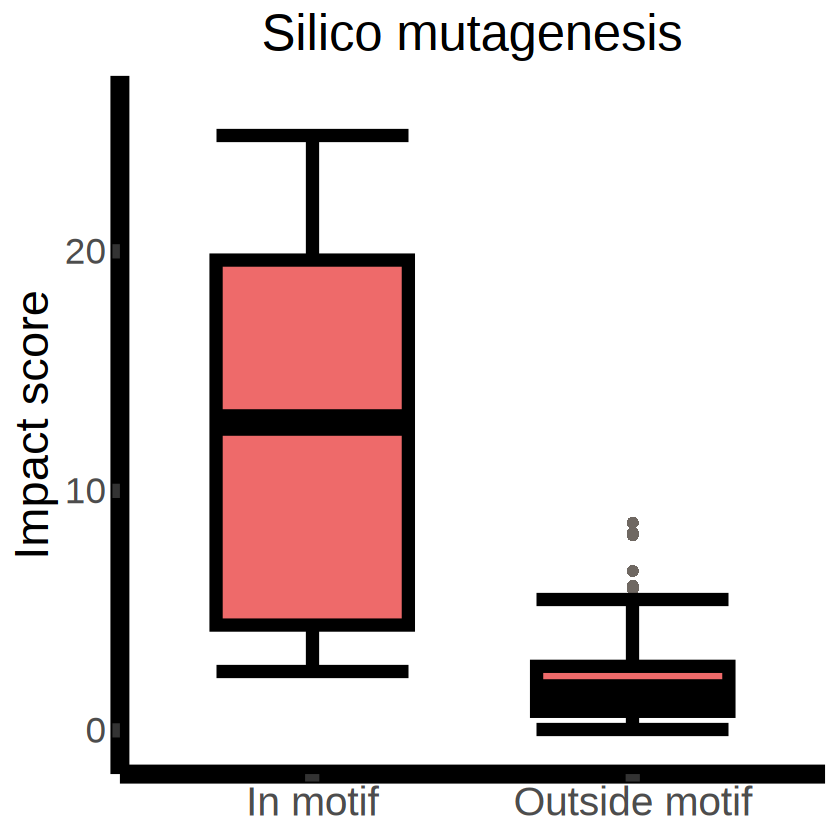

In [1]:
library(readr)
library(dplyr)
library(tidyr)
library(ggplot2)

fp <- "../../results/variant/inout_motif.csv"

# ---- 1) Robust read: try TSV first; if it collapses into 1 column, try CSV ----
df <- read_delim(fp, delim = "\t", comment = "#", col_types = cols(), trim_ws = TRUE)
if (ncol(df) == 1) {
  df <- read_delim(fp, delim = ",", comment = "#", col_types = cols(), trim_ws = TRUE)
}

# ---- 2) Normalize column names (handle dots/underscores/spaces) ----
names(df) <- trimws(names(df))
names(df) <- gsub("[._]+", " ", names(df))   # '.' and '_' -> space
names(df) <- gsub("\\s+", " ", names(df))    # collapse multiple spaces

# ---- 3) Rename target columns to exact strings used downstream ----
# Outside motif
if (!("Outside motif" %in% names(df))) {
  nm <- grep("outside\\s*motif", names(df), ignore.case = TRUE, value = TRUE)
  if (length(nm) >= 1) names(df)[names(df) == nm[1]] <- "Outside motif"
}
# In motif
if (!("In motif" %in% names(df))) {
  nm <- grep("^in\\s*motif$", names(df), ignore.case = TRUE, value = TRUE)
  if (length(nm) >= 1) names(df)[names(df) == nm[1]] <- "In motif"
}

stopifnot("Outside motif" %in% names(df), "In motif" %in% names(df))

# ---- 4) Wide -> long; drop missing/invalid values ----
df_long <- df %>%
  pivot_longer(cols = c("Outside motif", "In motif"),
               names_to = "Group", values_to = "Impact score") %>%
  filter(is.finite(`Impact score`), !is.na(`Impact score`)) %>%
  mutate(Group = factor(Group, levels = c("In motif", "Outside motif")))  # order on x-axis

# ---- 5) Boxplot: KEEP whisker caps by setting staplewidth explicitly ----
p <- ggplot(df_long, aes(x = Group, y = `Impact score`)) +
  geom_boxplot(
    width = 0.60,
    staplewidth = 1.00,        # <-- controls whisker cap width; increase if still too subtle
    fill = "#ee6a6a",
    color = "black",
    linewidth = 2.8,
    outlier.colour = "#6f6862",
    outlier.shape = 16,
    outlier.size = 2.8
  ) +
  labs(title = "Silico mutagenesis", x = NULL, y = "Impact score") +
  coord_cartesian(ylim = c(-0.5, 26)) +
  theme_classic(base_size = 18) +
  theme(
    plot.title  = element_text(size = 30, hjust = 0.5),
    axis.title.y = element_text(size = 28),
    axis.text.x = element_text(size = 24),
    axis.text.y = element_text(size = 22),
    axis.line   = element_line(linewidth = 4.0),
    axis.ticks  = element_line(linewidth = 3.0)
  )

print(p)
